# EDA & Preprocessing

**Dataset:** `dataset CS:GO esport matches round data yang disimpan dengan nama dataset.csv`                     
**Sumber Dataset:** https://www.kaggle.com/datasets/livanoff/csgo-esport-matches-round-data       
**Target Prediksi:** `winningSide` (CT / T)  
**Output akan disimpan di:** `preprocessing/csgo_preprocessed/`

---

## 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

## 2. Load dataset

In [2]:
df = pd.read_csv('dataset_match_cs/dataset.csv', index_col=0)

print('INFORMASI DATASET')
print('=' * 50)
print(f'Jumlah baris    : {df.shape[0]:,}')
print(f'Jumlah kolom    : {df.shape[1]}')
print('5 Baris Pertama:')
df.head()

INFORMASI DATASET
Jumlah baris    : 74,929
Jumlah kolom    : 20
5 Baris Pertama:


,mapName,roundNum,tScore,ctScore,endTScore,endCTScore,ctTeam,tTeam,roundEndReason,ctFreezeTimeEndEqVal,ctRoundStartEqVal,ctRoundSpendMoney,ctBuyType,tFreezeTimeEndEqVal,tRoundStartEqVal,tRoundSpendMoney,tBuyType,winningSide,winningTeam,losingTeam
0,de_ancient,1,0,0,0,1,LDLC OL,Team 500,BombDefused,4300,1000,3300,Full Eco,5000,1000,3300,Semi Eco,CT,LDLC OL,Team 500
1,de_ancient,2,0,1,0,2,LDLC OL,Team 500,CTWin,21550,3350,19500,Full Buy,14450,1000,14050,Semi Buy,CT,LDLC OL,Team 500
2,de_ancient,3,0,2,0,3,LDLC OL,Team 500,CTWin,23400,18800,4800,Full Buy,2500,1000,3750,Full Eco,CT,LDLC OL,Team 500
3,de_ancient,4,0,3,1,3,LDLC OL,Team 500,TargetBombed,30700,9950,20950,Full Buy,24400,1000,23600,Full Buy,T,Team 500,LDLC OL
4,de_ancient,5,1,3,2,3,LDLC OL,Team 500,TargetBombed,22950,5400,18550,Full Buy,27250,14750,12500,Full Buy,T,Team 500,LDLC OL


## 3. Exploratory Data Analysis (EDA)

### info data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74929 entries, 0 to 74928
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   mapName               74929 non-null  object
 1   roundNum              74929 non-null  int64 
 2   tScore                74929 non-null  int64 
 3   ctScore               74929 non-null  int64 
 4   endTScore             74929 non-null  int64 
 5   endCTScore            74929 non-null  int64 
 6   ctTeam                74917 non-null  object
 7   tTeam                 74918 non-null  object
 8   roundEndReason        74929 non-null  object
 9   ctFreezeTimeEndEqVal  74929 non-null  int64 
 10  ctRoundStartEqVal     74929 non-null  int64 
 11  ctRoundSpendMoney     74929 non-null  int64 
 12  ctBuyType             74929 non-null  object
 13  tFreezeTimeEndEqVal   74929 non-null  int64 
 14  tRoundStartEqVal      74929 non-null  int64 
 15  tRoundSpendMoney      74929 non-null  int

### deskripsi data

In [4]:
df.describe()

,roundNum,tScore,ctScore,endTScore,endCTScore,ctFreezeTimeEndEqVal,ctRoundStartEqVal,ctRoundSpendMoney,tFreezeTimeEndEqVal,tRoundStartEqVal,tRoundSpendMoney
count,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000,74929.000000
mean,14.226561,6.652391,6.606774,7.154359,7.104712,21813.640913,8395.274860,13903.690827,20175.813770,6592.743797,14057.695285
std,8.522251,4.710731,4.772876,4.750421,4.829139,10158.787439,7731.605647,8117.264297,8667.655504,7007.134969,7729.083392
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,3.000000,3.000000,3.000000,12950.000000,1000.000000,7300.000000,16050.000000,1000.000000,7900.000000
50%,14.000000,6.000000,6.000000,7.000000,7.000000,26200.000000,6300.000000,14300.000000,24000.000000,1000.000000,14350.000000
75%,21.000000,10.000000,10.000000,11.000000,11.000000,29900.000000,14600.000000,19700.000000,27050.000000,12300.000000,20600.000000
max,67.000000,33.000000,32.000000,33.000000,33.000000,38600.000000,32400.000000,45000.000000,33150.000000,28250.000000,39600.000000


### cek missing value

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
ctTeam         12
tTeam          11
winningTeam    12
losingTeam     13
dtype: int64


### Visualisasi

**1. class balance untuk side yang menang**

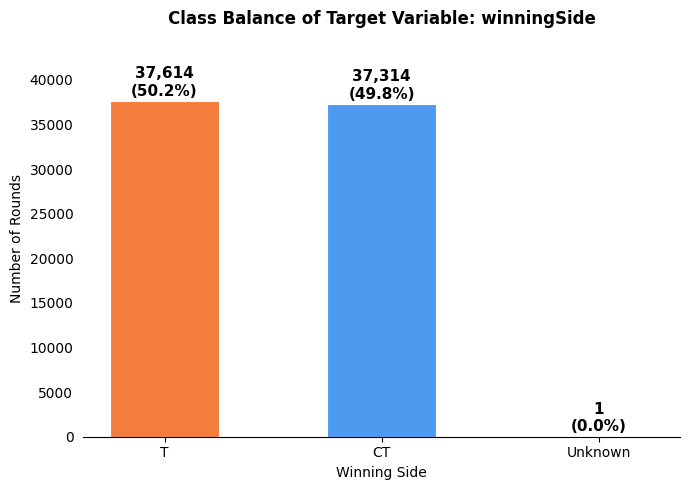

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = df['winningSide'].value_counts()
palette = {'CT': '#4E9AF1', 'T': '#F47C3C', 'Unknown': '#A0A0A0'}
bar_colors = [palette.get(label, '#888888') for label in counts.index]

bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)

total = counts.sum()
for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 250,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Balance of Target Variable: winningSide', fontweight='bold', pad=12)
ax.set_xlabel('Winning Side')
ax.set_ylabel('Number of Rounds')
ax.set_ylim(0, counts.max() * 1.18)
ax.tick_params(left=False)
sns.despine(left=True)

plt.tight_layout()
plt.show()

**2. jumlah kemenangan tiap side pada setiap map**

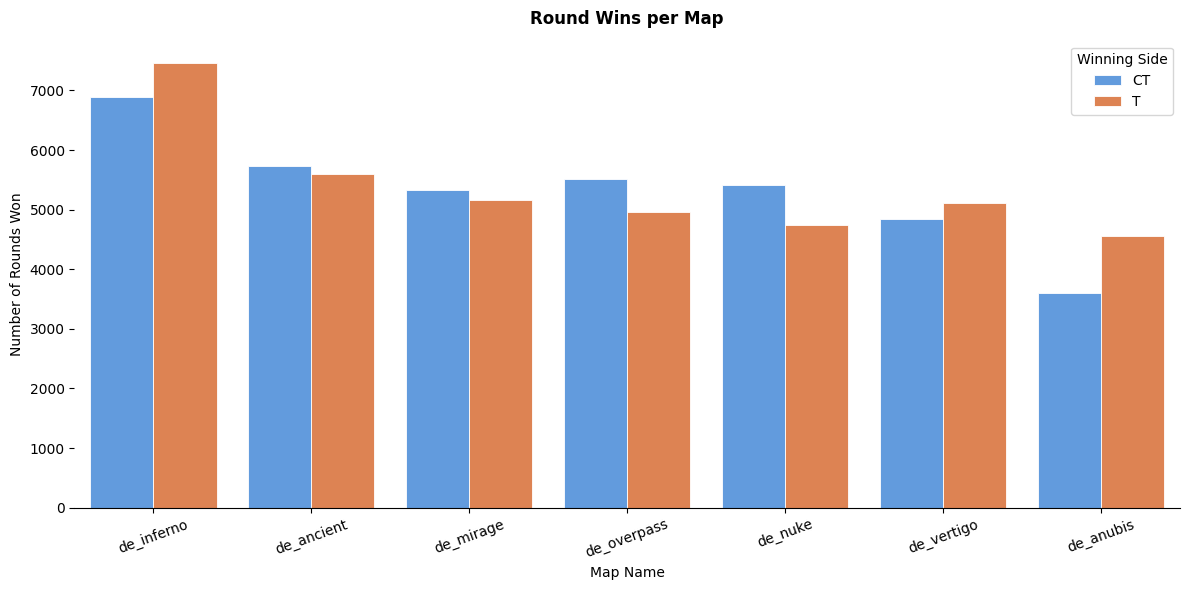

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

df_plot = df[df['winningSide'] != 'Unknown'].copy()

sns.countplot(
    data=df_plot,
    x='mapName',
    hue='winningSide',
    palette={'CT': '#4E9AF1', 'T': '#F47C3C'},
    edgecolor='white',
    linewidth=0.6,
    order=df_plot['mapName'].value_counts().index,
    ax=ax
)

ax.set_title('Round Wins per Map', fontweight='bold', pad=12)
ax.set_xlabel('Map Name')
ax.set_ylabel('Number of Rounds Won')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Winning Side', frameon=True, framealpha=0.8)
sns.despine(left=True)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Pada tahap ini akan dilakukan

1. pembersihan data yang ada winning side nya unknown
2. menghapus data leakage dan kolom kolom yang kurang relevan
3. memisahkan feature (x) dan target (y)
4. encoding
5. split data train dan test (80/20, pake `random_state=42`)
6. StandardScaler

In [8]:
before = len(df)
df = df[df['winningSide'] != 'Unknown'].copy()
print(f'Rows before: {before}  |  Rows after: {len(df)}  |  Dropped: {before - len(df)}')

Rows before: 74929  |  Rows after: 74928  |  Dropped: 1


In [9]:
DROP_COLUMNS = [
    'endTScore',      # data leakage
    'endCTScore',     # data leakage
    'ctTeam',         # ga terlalu relevan
    'tTeam',          # ga terlalu relevan
    'roundEndReason', # data leakage
    'winningTeam',    # data leakage
    'losingTeam',     # data leakage
]

df = df.drop(columns=DROP_COLUMNS)
print('Sisa columns:', list(df.columns))
print(f'Jumlah kolom sekarang : {df.shape[1]}')

Sisa columns: ['mapName', 'roundNum', 'tScore', 'ctScore', 'ctFreezeTimeEndEqVal', 'ctRoundStartEqVal', 'ctRoundSpendMoney', 'ctBuyType', 'tFreezeTimeEndEqVal', 'tRoundStartEqVal', 'tRoundSpendMoney', 'tBuyType', 'winningSide']
Jumlah kolom sekarang : 13


In [10]:
y = df['winningSide']
X = df.drop('winningSide', axis=1)

print('Feature matrix shape:', X.shape)
print('Target vector shape :', y.shape)
print('Feature columns     :', list(X.columns))

Feature matrix shape: (74928, 12)
Target vector shape : (74928,)
Feature columns     : ['mapName', 'roundNum', 'tScore', 'ctScore', 'ctFreezeTimeEndEqVal', 'ctRoundStartEqVal', 'ctRoundSpendMoney', 'ctBuyType', 'tFreezeTimeEndEqVal', 'tRoundStartEqVal', 'tRoundSpendMoney', 'tBuyType']


In [11]:
CATEGORICAL_FEATURES = ['mapName', 'ctBuyType', 'tBuyType']

le_features = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X = X.copy()
    X[col] = le.fit_transform(X[col])
    le_features[col] = le
    print(f'  {col}: {list(le.classes_)}')

print('\nX head after encoding:')
X.head()

  mapName: ['de_ancient', 'de_anubis', 'de_inferno', 'de_mirage', 'de_nuke', 'de_overpass', 'de_vertigo']
  ctBuyType: ['Full Buy', 'Full Eco', 'Semi Buy', 'Semi Eco']
  tBuyType: ['Full Buy', 'Full Eco', 'Semi Buy', 'Semi Eco']

X head after encoding:


,mapName,roundNum,tScore,ctScore,ctFreezeTimeEndEqVal,ctRoundStartEqVal,ctRoundSpendMoney,ctBuyType,tFreezeTimeEndEqVal,tRoundStartEqVal,tRoundSpendMoney,tBuyType
0,0,1,0,0,4300,1000,3300,1,5000,1000,3300,3
1,0,2,0,1,21550,3350,19500,0,14450,1000,14050,2
2,0,3,0,2,23400,18800,4800,0,2500,1000,3750,1
3,0,4,0,3,30700,9950,20950,0,24400,1000,23600,0
4,0,5,1,3,22950,5400,18550,0,27250,14750,12500,0


In [12]:
le_target = LabelEncoder()
y = pd.Series(le_target.fit_transform(y), name='winningSide', index=y.index)

print('Target classes:', le_target.classes_, '-> encoded as', list(range(len(le_target.classes_))))
print('Target value counts:\n', y.value_counts())

Target classes: ['CT' 'T'] -> encoded as [0, 1]
Target value counts:
 winningSide
1    37614
0    37314
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)

X_train shape: (59942, 12)
X_test  shape: (14986, 12)
y_train shape: (59942,)
y_test  shape: (14986,)


In [14]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Scaler fitted on training data only.')
print('X_train_scaled head:')
X_train_scaled.head()

Scaler fitted on training data only.
X_train_scaled head:


,mapName,roundNum,tScore,ctScore,ctFreezeTimeEndEqVal,ctRoundStartEqVal,ctRoundSpendMoney,ctBuyType,tFreezeTimeEndEqVal,tRoundStartEqVal,tRoundSpendMoney,tBuyType
12278,-1.500723,0.792105,0.284134,1.127650,0.889756,1.132438,-0.024932,-0.584915,-1.553803,-0.798418,-0.734171,2.662310
31837,-0.484738,0.206151,-0.140011,0.499669,-1.735642,-0.957502,-1.294134,0.499422,-1.831097,-0.798418,-1.387093,0.482704
61637,-1.500723,-0.145422,-0.776230,0.499669,0.254341,-0.957502,1.552328,-0.584915,0.791636,-0.170389,1.017726,-0.607098
957,0.023255,1.026487,1.556571,0.290342,-1.208592,-0.148702,-1.331101,2.668096,0.872514,0.664603,0.338947,-0.607098
65193,0.531247,0.557724,0.920352,0.081015,0.781391,-0.226347,1.342848,-0.584915,0.317927,1.692286,-1.212549,-0.607098


In [15]:
OUTPUT_DIR = 'csgo_preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = X_train_scaled.copy()
train_df['winningSide'] = y_train.values

test_df = X_test_scaled.copy()
test_df['winningSide'] = y_test.values

train_path = os.path.join(OUTPUT_DIR, 'train_clean.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test_clean.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print('Saved:', train_path, '| shape:', train_df.shape)
print('Saved:', test_path,  '| shape:', test_df.shape)
print('\nPreprocessing complete!')

Saved: csgo_preprocessed/train_clean.csv | shape: (59942, 13)
Saved: csgo_preprocessed/test_clean.csv | shape: (14986, 13)

Preprocessing complete!
